<a href="https://colab.research.google.com/github/youngPath12/microbiom-team-1/blob/Sujin/METIS_Optimization_Notebook_AI%20%EC%8A%A4%EC%BC%80%EC%9D%BC%EC%97%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>METIS</h1>
<h3>Optimization Notebook</h3>
Before use, read figure 2, Supplementary Note 2 and Supplementary Figures 4-6 of the METIS publication at: <a>biorxiv.org/content/10.1101/2021.12.28.474323v2</a>

In [ ]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
import time
from sklearn.model_selection import RandomizedSearchCV
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt
from collections.abc import Iterable
import math
import random
from scipy.stats import spearmanr, pearsonr

pd.options.mode.chained_assignment = None  # default='warn'
!wget https://raw.githubusercontent.com/amirpandi/METIS/main/utils.py

from utils import *

--2026-09-04 07:20:36--  https://raw.githubusercontent.com/amirpandi/METIS/main/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29949 (29K) [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]  29.25K  --.-KB/s    in 0s      

2026-09-04 07:20:36 (117 MB/s) - ‘utils.py’ saved [29949/29949]



# Help for each imported function is available:

In [ ]:
help(random_combination_generator)

Help on function random_combination_generator in module utils:

random_combination_generator(
    concentrations_limits,
    number_of_combination=100,
    reaction_vol_nl=10000,
    max_nl=None,
    drop_size_nl=100,
    check_repeat=True,
    rounded=2,
    verbose=0,
    make_csv=False,
    return_df=False
)
    this function make random combination that is safe (e.g. dont make too much or low concentrated, not excecutable based on drop size, not repetitive)

    Parameters
    ----------
    concentrations_limits: dict
        {'name of metabolite': {'Conc_Min': #, 'Conc_Max': #, 'Conc_Values': #, 'Conc_Stock': #, 'Alternatives': #}, ...}

    Returns
    -------
    data: pandas.DataFrame
        a dataframe as consists of number_of_combination of random combinations



This notebook includes all data processing, active learning, results analysis and visualization.

# User Inputs

<p1><h2> When to use this part:</h2>
* every time before using MLOP you should fill this part based on your project</p1>
<p1><h2> How to use this part:</h2>
* User should upload all available Results file (i.e. Results_1.csv to Results_n.csv) to runtime from Files/UploadFile
* now there is an example, change it to your project</p1>

In [ ]:
# General Parameters:
m = 4      # number_of_combination_each_round //m=12 로 바꿔서 팀원들 전체 data를 먼저 넣기루
minimum_drop_size_nanoliter = 1000
final_reaction_volume_nanoliter = 1000000
maximum_volume_of_model_output = 750000 # (i. e., total volume minus fixed parts/components. Avoid 0 for water.)
fixed_parts = {'Fixed':0.25} # 33% of total volume is Lysate, 15% energy mix (except variable one), 2.5% IPTG
days_total = 10 # how many days you want to continue # set it at your max prediction

# Model Parameters:
RandomCV = True
n_iter = 200
ensemble_len = 20
exploration = {1: 1.41, 2: 1.41, 3: 1.41,
               4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0,
               8: 0.5, 9: 0.5, 10: 0.5}
days_range = [m for i in range(days_total)]

**metabolite name must not include "_"**


In [ ]:
concentrations_limits = {
    'Peptone': {
        'Conc_Min': None,
        'Conc_Max': None,
        'Conc_Values': [1.0, 5.0, 10.0, 20.0],
        'Conc_Stock': 200.0,
        'Alternatives': None
    },
    'Meat': {
        'Conc_Min': 0.0,
        'Conc_Max': 16.0,
        'Conc_Values': None,
        'Conc_Stock': 160.0,
        'Alternatives': None
    },
    'Yeast': {
        'Conc_Min': 0.0,
        'Conc_Max': 8.0,
        'Conc_Values': None,
        'Conc_Stock': 80.0,
        'Alternatives': None
    },
    'Glucose': {
        'Conc_Min': None,
        'Conc_Max': None,
        'Conc_Values': [1.0, 10.0, 20.0, 30.0, 400.0],
        'Conc_Stock': 200.0,
        'Alternatives': None
    }
}

In [ ]:
# Check Possible Concentrations
data_lists = {}
num = 0

pool_size = 1

for key, value in concentrations_limits.items():
    print('Possible Conc For :',key)
    if not value['Conc_Values']:
        print('Your Min, Max :', "({}, {})".format(value['Conc_Min'], value['Conc_Max']))
    concs, vols = allowed_output(value, reaction_vol_nl = final_reaction_volume_nanoliter, drop_size_nl = minimum_drop_size_nanoliter, verbose=0)
    print(concs)
    print(vols)

    pool_size *= len(concs)

    data_lists[num] = vols
    num += 1
    print()

print('All Possible Combination Number = ', pool_size)
if pool_size > 10000000:
    pool_size = 10000000
    print('Percentage calculation is not availbe duo to large pool size!')
else:
    percent , pool_size = percentage_possible(data_lists, threshold = maximum_volume_of_model_output)
    print(percent, f'% of {pool_size} possible combination are executable!')

Possible Conc For : Peptone
[1.0, 5.0, 10.0, 20.0]
[5000.0, 25000.0, 50000.0, 100000.0]

Possible Conc For : Meat
Your Min, Max : (0.0, 16.0)
[0.0, 0.16, 0.32, 0.48, 0.64, 0.8, 0.96, 1.12, 1.28, 1.44, 1.6, 1.76, 1.92, 2.08, 2.24, 2.4, 2.56, 2.72, 2.88, 3.04, 3.2, 3.36, 3.52, 3.68, 3.84, 4.0, 4.16, 4.32, 4.48, 4.64, 4.8, 4.96, 5.12, 5.28, 5.44, 5.6, 5.76, 5.92, 6.08, 6.24, 6.4, 6.56, 6.72, 6.88, 7.04, 7.2, 7.36, 7.52, 7.68, 7.84, 8.0, 8.16, 8.32, 8.48, 8.64, 8.8, 8.96, 9.12, 9.28, 9.44, 9.6, 9.76, 9.92, 10.08, 10.24, 10.4, 10.56, 10.72, 10.88, 11.04, 11.2, 11.36, 11.52, 11.68, 11.84, 12.0, 12.16, 12.32, 12.48, 12.64, 12.8, 12.96, 13.12, 13.28, 13.44, 13.6, 13.76, 13.92, 14.08, 14.24, 14.4, 14.56, 14.72, 14.88, 15.04, 15.2, 15.36, 15.52, 15.68, 15.84, 16.0]
[0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000, 26000, 27000, 28000, 29000, 30000, 31000, 32000, 33000, 34000, 3

In [ ]:
# add reference and negative control, these combinations will be implemented in concentrations and volume files
# leave it empty if you dont need, but still you need to run this cell
# you can add more desired combination to this dictionary
# *** conc in these dic must be compatible with minimum drop size ***, for help you can see our other examples on METIS Github repo

specials = {}

# Day 1 (in absence of Day_0)

<p1><h2> When to use this part:</h2>
* after filling "User Input" if you have no pre existing data (Day_0.csv)
<p1><h2> How to use this part:</h2>
* just run all cells! and download the output concentration and volume files from the folder at left.


In [ ]:
# make random combinations
Concentrations_1 = random_combination_generator(concentrations_limits, number_of_combination = m,
                                                reaction_vol_nl=final_reaction_volume_nanoliter,
                                                max_nl=maximum_volume_of_model_output, drop_size_nl=minimum_drop_size_nanoliter, return_df=True)

# add control, reference and other desired combinations
df_specials = [pd.DataFrame(i) for i in specials.values()]
Concentrations_1 = pd.concat([Concentrations_1, *df_specials]).reset_index(drop=True)

Concentrations_1

,Peptone,Meat,Yeast,Glucose
0,20.0,10.24,0.72,10.0
1,20.0,14.72,0.96,10.0
2,10.0,7.04,2.08,10.0
3,10.0,9.44,2.88,30.0


In [ ]:
!mkdir -p Day_1
Concentrations_1.to_csv('Day_1/Concentrations_1.csv', index=False)

In [ ]:
# concentration_to_volume
Volumes_1 = concentration_to_volume(Concentrations_1, concentrations_limits, reaction_mixture_vol_nl=final_reaction_volume_nanoliter,
                                    fixed_parts=fixed_parts)
Volumes_1.to_csv('Day_1/Volumes_1.csv', index=False)
Volumes_1

,Peptone,Meat,Yeast,Glucose,Fixed,water
0,100000.0,64000.0,9000.0,50000.0,250000.0,527000.0
1,100000.0,92000.0,12000.0,50000.0,250000.0,496000.0
2,50000.0,44000.0,26000.0,50000.0,250000.0,580000.0
3,50000.0,59000.0,36000.0,150000.0,250000.0,455000.0


# Other Days

<p1><h2> When to use this part:</h2>
* when you have either pre existing data (Results_0.csv) or Results_1 to Results_n uploaded into the main directory at left.
<p1><h2> How to use this part:</h2>
* just run all cells!

In [ ]:
day = day_finder('Results') - 1
start_day = (1, 0)[os.path.isfile('Results_0.csv')]
print(start_day, day)

1 0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


컬럼명 확인: ['Peptone', 'Meat', 'Yeast', 'Glucose', 'yield']
    Peptone   Meat  Yeast  Glucose  yield
0        20  12.80   0.48       20  0.712
1         5   8.96   0.08       30  0.879
2        10  15.20   3.68       10  0.801
3         5   4.00   3.44        1  0.812
4         5   8.16   3.36       30  0.796
5         1  13.76   7.68        1  0.602
6         5  15.68   8.00       30  0.571
7        10   8.96   6.48       30  0.726
8        10   1.12   4.48       20  0.703
9        10  11.52   6.24        1  0.799
10        5   0.00   7.60       30  0.758
11        5  15.20   0.00       20  0.761
RandomizedSearchCV 학습 중...
앙상블 학습 완료: 20 개 모델
소요 시간(초): 6.489657163619995

=== Day 2 추천 조합 ===
   Peptone   Meat  Yeast  Glucose
0      5.0  11.68   3.84      1.0
1      5.0  11.52   3.84     10.0
2      5.0  12.00   4.32     10.0
3      5.0  11.84   4.08     10.0


/content/utils.py:467: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chosen_combinations = pd.concat([chosen_combinations, temp_combination]).reset_index(drop=True)



=== Day 2 부피(volume) ===
   Peptone     Meat    Yeast  Glucose     Fixed     water
0  25000.0  73000.0  48000.0   5000.0  250000.0  599000.0
1  25000.0  72000.0  48000.0  50000.0  250000.0  555000.0
2  25000.0  75000.0  54000.0  50000.0  250000.0  546000.0
3  25000.0  74000.0  51000.0  50000.0  250000.0  550000.0


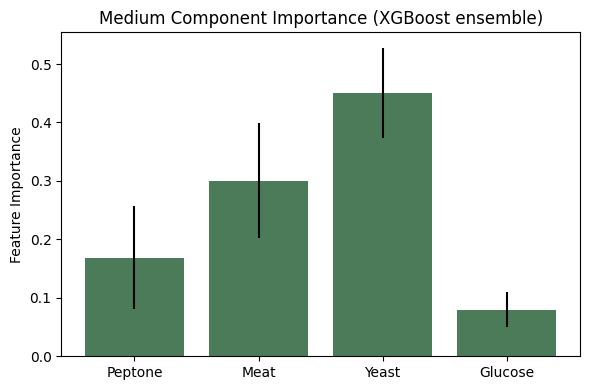

In [ ]:
import pandas as pd, numpy as np, time
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# --- 1. Results_1.csv를 BOM/줄바꿈 문제 없이 안전하게 읽기 ---
final_order = list(concentrations_limits.keys())  # ['Peptone','Meat','Yeast','Glucose']

Results_1 = pd.read_csv('Results_1.csv', encoding='utf-8-sig')  # utf-8-sig가 BOM 자동 제거
Results_1.columns = Results_1.columns.str.strip()  # 혹시 모를 공백도 제거
print("컬럼명 확인:", list(Results_1.columns))
print(Results_1)

aggregated_data_m = Results_1[final_order].reset_index(drop=True)
aggregated_label_m = Results_1[['yield']].reset_index(drop=True)

# --- 2. XGBoost 앙상블 학습 ---
model = XGBRegressor(objective='reg:squarederror')
param_grid = {
    "learning_rate": [0.01, 0.03, 0.1, 0.3], "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
    "subsample": [0.6, 0.8, 0.9, 1.0], "max_depth": [2, 3, 4, 6, 8],
    "n_estimators": [10, 20, 40, 60, 80, 100, 300, 500], "reg_lambda": [1, 1.5, 2],
    "gamma": [0, 0.1, 0.4, 0.6], "min_child_weight": [1, 2, 4]
}
grid = RandomizedSearchCV(estimator=model, param_distributions=param_grid, cv=4,
                           scoring='neg_mean_absolute_error', n_jobs=-1, n_iter=n_iter)
print("RandomizedSearchCV 학습 중...")
grid.fit(aggregated_data_m.values, aggregated_label_m.values.ravel())
results_cv = pd.DataFrame(grid.cv_results_).sort_values('mean_test_score', ascending=False)
regressors_list = [XGBRegressor(objective='reg:squarederror', **p) for p in results_cv.params.iloc[0:ensemble_len]]
for r in regressors_list:
    r.fit(aggregated_data_m.values, aggregated_label_m.values.ravel())
print("앙상블 학습 완료:", len(regressors_list), "개 모델")

# --- 3. Day 2 추천 조합 생성 ---
t0 = time.time()
Concentrations_2 = bayesian_optimization(
    regressors_list, aggregated_data_m, aggregated_label_m, concentrations_limits,
    final_order=final_order, df_main=aggregated_data_m,
    reaction_vol_nl=final_reaction_volume_nanoliter, max_nl=maximum_volume_of_model_output,
    drop_size_nl=minimum_drop_size_nanoliter,
    exploitation=1, exploration=exploration[2], test_size=m, pool_size=10000, verbose=0,
    day=1, days_range=days_range
)
print("소요 시간(초):", time.time()-t0)
print("\n=== Day 2 추천 조합 ===")
print(Concentrations_2)

# --- 4. 저장 ---
!mkdir -p Day_2
Concentrations_2.to_csv('Day_2/Concentrations_2.csv', index=False)
Volumes_2 = concentration_to_volume(Concentrations_2, concentrations_limits,
                                     reaction_mixture_vol_nl=final_reaction_volume_nanoliter, fixed_parts=fixed_parts)
Volumes_2.to_csv('Day_2/Volumes_2.csv', index=False)
print("\n=== Day 2 부피(volume) ===")
print(Volumes_2)

# --- 5. Feature Importance ---
import matplotlib.pyplot as plt
importances = np.array([r.feature_importances_ for r in regressors_list])
mean_imp = importances.mean(axis=0)
std_imp = importances.std(axis=0)
plt.figure(figsize=(6,4))
plt.bar(final_order, mean_imp, yerr=std_imp, color='#4C7B5A')
plt.ylabel('Feature Importance')
plt.title('Medium Component Importance (XGBoost ensemble)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

(실행한 것) 12개 실측 데이터로 앙상블 학습 → Feature Importance

(목적) "어떤 배지 성분이 수율에 가장 영향력이 큰가?"

(결과) Yeast(45%) > Meat(30%) > Peptone(17%) > Glucose(8%)

In [ ]:
# 학습된 앙상블로 전체 탐색공간에서 예측 최고 수율 조합 찾기
pool = random_combination_generator(concentrations_limits, number_of_combination=5000,
                                     reaction_vol_nl=final_reaction_volume_nanoliter,
                                     max_nl=maximum_volume_of_model_output,
                                     drop_size_nl=minimum_drop_size_nanoliter, return_df=True)

preds = np.mean([r.predict(pool[final_order].values) for r in regressors_list], axis=0)
pool['predicted_yield'] = preds
top5 = pool.sort_values('predicted_yield', ascending=False).head(5)
print("=== AI 예측 최적 배지 조성 Top 5 ===")
print(top5)

=== AI 예측 최적 배지 조성 Top 5 ===
      Peptone   Meat  Yeast  Glucose  predicted_yield
3770      5.0  10.24   0.16     10.0         0.856411
3049      5.0   9.92   0.40     10.0         0.856411
2402      5.0  10.88   0.40     10.0         0.856411
143       5.0  10.56   0.24     10.0         0.856411
150       5.0   9.76   0.24      1.0         0.856071


In [ ]:
t0 = time.time()

pool_size = 10000 # for when you want to change pool size, default = all possible combinations

Concentrations_n_m = bayesian_optimization(regressors_list, aggregated_data_m, aggregated_label_m, concentrations_limits,
                                           final_order=final_order,
                                           df_main = aggregated_data_m,
                                           reaction_vol_nl=final_reaction_volume_nanoliter, max_nl=maximum_volume_of_model_output,
                                           drop_size_nl=minimum_drop_size_nanoliter,
                                           exploitation=1, exploration=exploration[day+1], test_size=m, pool_size=pool_size, verbose=0,
                                           day=day, days_range = days_range)

print("Passed Time(s): ",time.time()-t0)

Concentrations_n_m

Passed Time(s):  12.161062955856323


/content/utils.py:467: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chosen_combinations = pd.concat([chosen_combinations, temp_combination]).reset_index(drop=True)


,Peptone,Meat,Yeast,Glucose
0,10.0,12.96,4.32,30.0
1,5.0,15.36,6.08,10.0
2,10.0,2.40,1.68,30.0
3,20.0,10.88,4.40,20.0


In [ ]:
# add control, reference and other desired combinations
df_specials = [pd.DataFrame(i) for i in specials.values()]
Concentrations_n = pd.concat([Concentrations_n_m, *df_specials]).reset_index(drop=True)

name_folder = 'Day_{}'.format(day+1)
! mkdir -p {name_folder}

Concentrations_n.to_csv('Day_{}/Concentrations_{}.csv'.format(day+1, day+1), index=False)

In [ ]:
# check not to make repeated combination
df_main = aggregated_data_m

comparison_df = df_main.merge(pd.read_csv('Day_{}/Concentrations_{}.csv'.format(day+1, day+1)).iloc[:m,:],
                              indicator=True,
                              how='outer')

comparison_df._merge.unique()

['right_only']
Categories (3, object): ['left_only', 'right_only', 'both']

In [ ]:
# concentration_to_volume
Volumes_n = concentration_to_volume(Concentrations_n, concentrations_limits, reaction_mixture_vol_nl=final_reaction_volume_nanoliter, fixed_parts=fixed_parts)

Volumes_n.to_csv('Day_{}/Volumes_{}.csv'.format(day+1, day+1), index=False)

# Visualising Results as BoxPlot


<p1><h2> When to use this part:</h2>
* you have at least one Results.csv file
<p1><h2> How to use this part:</h2>
* just run all cells!
* you can change plotting parameter

In [ ]:
display_std = True # if you have included "yield_std" column in Results.csv will show it else disply 0 for std

day = day_finder('Results')
start_day = (1, 0)[os.path.isfile('Results_0.csv')]

Results_m = pd.DataFrame(columns=['yield', 'std', 'Day'])
for i in range(start_day, day):
    Results_i = pd.DataFrame(columns=['yield', 'std', 'Day'])
    if start_day:
        Results_i['yield'] = pd.read_csv(f'Results_{i}.csv')['yield'].iloc[0:days_range[i-1]]
    else:
        Results_i['yield'] = pd.read_csv(f'Results_{i}.csv')['yield'].iloc[0:len(pd.read_csv('Results_0.csv'))]

    try:
        if start_day:
            Results_i['std'] = pd.read_csv(f'Results_{i}.csv')['yield_std'].iloc[0:days_range[i-1]]
        else:
            Results_i['std'] = pd.read_csv(f'Results_{i}.csv')['yield_std'].iloc[0:len(pd.read_csv('Results_0.csv'))]

    except:
        Results_i['std'] = 0
    Results_i['Day'] = i
    Results_m = pd.concat([Results_m, Results_i])

sns.set_style('whitegrid') # Using sns.set_style for Seaborn styles
# plt.style.use('seaborn-poster') # Removed problematic style
fig, ax = plt.subplots(1, 1)

#ax = sns.boxplot(x='Day', y='yield', data=Results_m, color='#4BC15F', fliersize=0)
ax = sns.boxplot(x='Day', y='yield', data=Results_m, color='#00A368', fliersize=0)

ax = sns.swarmplot(x='Day', y='yield', data=Results_m, color='k', size=10)

if display_std:
    # Find the x,y coordinates for each point
    order = 0
    for point_pair in ax.collections:
        for x, y in point_pair.get_offsets():
            std = Results_m.sort_values(['Day', 'yield'], ignore_index=True)['std'][order]
            y_Result = Results_m.sort_values(['Day', 'yield'], ignore_index=True)['yield'][order]
            ax.arrow(x, y-(std/2), dx=0, dy=std, linewidth=1, zorder=4, width=0, color='grey')

            order += 1

    errors = Results_m['std']

ax.set_ylim(top=350000)
ax

OSError: 'seaborn-poster' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

SAVE plots and download from the directory at left

In [ ]:
fig.savefig(f'#00A368_Day_{day-1}_Boxplot.png', format='png', dpi=1200)
fig.savefig(f'#00A368_Day_{day-1}_Boxplot.svg', format='svg', dpi=1200)

# Visualising Results For Each Metabolite

<p1><h2> When to use this part:</h2>
* you have at least one Results.csv file
<p1><h2> How to use this part:</h2>
* just run all cells!
* you can change plotting parameter

In [ ]:
desired_cols = []
day = day_finder('Results')
start_day = (1, 0)[os.path.isfile('Results_0.csv')]

for key, value in concentrations_limits.items():
    if value['Alternatives']:
        desired_cols.append(key)
        alternative_name = ['{}_{}'.format(key, i) for i in value['Alternatives']]
        desired_cols += alternative_name
    else:
        desired_cols.append(key)

final_order = desired_cols

aggregated_data_m = pd.DataFrame(columns=desired_cols)
aggregated_label_m = pd.DataFrame(columns=['yield'])

for num in range(start_day, day):
    if start_day:
        data_m, label_m, _, _= result_preprocess(num, desired_cols, days_range[num-1])
    else:
        data_m, label_m, _, _= result_preprocess(num, desired_cols, len(pd.read_csv('Results_0.csv')))

    aggregated_data_m = pd.concat([aggregated_data_m, data_m]).reset_index(drop=True)
    aggregated_label_m = pd.concat([aggregated_label_m, label_m]).reset_index(drop=True)

plt.style.use('seaborn-whitegrid')

num = len(desired_cols)
dim = math.ceil(math.sqrt(num))
data = pd.concat([aggregated_data_m, aggregated_label_m], axis=1)

import matplotlib as mpl


mpl.rcParams['axes.linewidth'] = 8.0 #set the value globally
mpl.rcParams['axes.edgecolor'] = 'black' #set the value globally
mpl.rcParams['xtick.major.pad'] = 10.0 #set the value globally
mpl.rcParams['ytick.major.pad'] = 10.0 #set the value globally

fig = plt.figure(figsize=(25,20))

for i in range(1, num+1):
    ax = plt.subplot(dim, dim, i)
    ax.xaxis.grid(False)
    ax = sns.scatterplot(x = desired_cols[i-1], y='yield', color='darkblue', data=data, s=120, linewidth=0)
    y_axis = ax.axes.get_yaxis()
    y_axis.set_label_text('foo')
    y_label = y_axis.get_label()
    ##print isinstance(x_label, matplotlib.artist.Artist)
    y_label.set_visible(False)
    #ax.xaxis.set_tick_params()
    plt.xticks(weight = 'bold', fontsize=18)
    plt.yticks(weight = 'bold', fontsize=18)

    plt.xlabel(desired_cols[i-1], labelpad=30 ,fontsize=25, weight='bold')


fig.tight_layout(h_pad=3, w_pad=3)

SAVE plots and download from the directory at left

In [ ]:
fig.savefig(f'Day_{day-1}_Metabolite_Yield.png', format='png', dpi=1200)
fig.savefig(f'Day_{day-1}_Metabolite_Yield.svg', format='svg', dpi=1200)

# Visualising Results For Each Metabolite (Beta)

In [ ]:
desired_cols_alternatives = []
desired_cols = []
alternative_dict = {}

day = day_finder('Results')
start_day = (1, 0)[os.path.isfile('Results_0.csv')]

for key, value in concentrations_limits.items():
    if value['Alternatives']:
        desired_cols.append(key)
        alternative_name = ['{}_{}'.format(key, i) for i in value['Alternatives']]
        desired_cols_alternatives += alternative_name
        alternative_dict[key] = alternative_name
    else:
        desired_cols.append(key)

final_order = desired_cols

aggregated_data_m = pd.DataFrame(columns=desired_cols + desired_cols_alternatives)
aggregated_label_m = pd.DataFrame(columns=['yield'])

for num in range(start_day, day):
    if start_day:
        data_m, label_m, _, _= result_preprocess(num, desired_cols + desired_cols_alternatives, days_range[num-1])
    else:
        data_m, label_m, _, _= result_preprocess(num, desired_cols + desired_cols_alternatives, len(pd.read_csv('Results_0.csv')))

    aggregated_data_m = pd.concat([aggregated_data_m, data_m]).reset_index(drop=True)
    aggregated_label_m = pd.concat([aggregated_label_m, label_m]).reset_index(drop=True)

In [ ]:
plt.style.use('seaborn-whitegrid')

num = len(desired_cols)
dim = math.ceil(math.sqrt(num))
data = pd.concat([aggregated_data_m, aggregated_label_m], axis=1)

import matplotlib as mpl


mpl.rcParams['axes.linewidth'] = 8.0 #set the value globally
mpl.rcParams['axes.edgecolor'] = 'black' #set the value globally
mpl.rcParams['xtick.major.pad'] = 10.0 #set the value globally
mpl.rcParams['ytick.major.pad'] = 10.0 #set the value globally

fig = plt.figure(figsize=(25,20))

for i in range(1, num+1):
    ax = plt.subplot(dim, dim, i)
    ax.xaxis.grid(False)
    ax = sns.scatterplot(x = desired_cols[i-1], y='yield', color='darkblue', data=data, s=120, linewidth=0)
    y_axis = ax.axes.get_yaxis()
    y_axis.set_label_text('foo')
    y_label = y_axis.get_label()
    ##print isinstance(x_label, matplotlib.artist.Artist)
    y_label.set_visible(False)
    #ax.xaxis.set_tick_params()
    plt.xticks(weight = 'bold', fontsize=18)
    plt.yticks(weight = 'bold', fontsize=18)

    plt.xlabel(desired_cols[i-1], labelpad=30 ,fontsize=25, weight='bold')


fig.tight_layout(h_pad=3, w_pad=3)

SAVE plots and download from the directory at left

In [ ]:
fig.savefig(f'Day_{day-1}_Metabolite_Yield_NoAlternative.png', format='png', dpi=1200)
fig.savefig(f'Day_{day-1}_Metabolite_Yield_NoAlternative.svg', format='svg', dpi=1200)

In [ ]:
temp_dict = {}
for key, value in alternative_dict.items():
    temp_dict[key] = {}
    for i in value:
        temp_dict[key][i] = []

data = pd.concat([aggregated_data_m, aggregated_label_m], axis=1)
for i in range(len(data)):
    for j in temp_dict.keys():
        for k in temp_dict[j].keys():
            if  data[desired_cols_alternatives].loc[i][k]:
                temp_dict[j][k].append(aggregated_label_m.loc[i]['yield'])

plt.style.use('seaborn-whitegrid')

num = len(temp_dict.keys())
dim = math.ceil(math.sqrt(num))

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 8.0 #set the value globally
mpl.rcParams['axes.edgecolor'] = 'black' #set the value globally
mpl.rcParams['xtick.major.pad'] = 10.0 #set the value globally
mpl.rcParams['ytick.major.pad'] = 10.0 #set the value globally

fig = plt.figure(figsize=(15,10))

for ind, main in enumerate(temp_dict.keys()):
    ax = plt.subplot(dim, dim, ind+1)
    temp_df = pd.DataFrame(columns=temp_dict[main].keys(), index=range(max([len(i) for i in temp_dict[main].values()])))
    for i in temp_dict[main].keys():
        temp_df[i].loc[0:len(temp_dict[main][i])-1] = temp_dict[main][i]

    sns.swarmplot(data=temp_df, ax=ax, size=10, palette=sns.color_palette(['goldenrod', 'royalblue' , 'firebrick', 'black']))


fig.tight_layout(h_pad=3, w_pad=3)

SAVE plots and download from the directory at left

In [ ]:
fig.savefig(f'Day_{day-1}_Metabolite_Yield_Alternative.png', format='png', dpi=1200)
fig.savefig(f'Day_{day-1}_Metabolite_Yield_Alternative.svg', format='svg', dpi=1200)

# Viualising Concentrations From Day_1 to Now

<p1><h2> When to use this part:</h2>
* you have at least one Results.csv file
<p1><h2> How to use this part:</h2>
* just run all cells!
* you can change plotting parameter

In [ ]:
data_all = pd.DataFrame(columns = list(concentrations_limits.keys())+['day'])
day = day_finder('Results')
desired_cols = []

# make column name:
desired_cols = []
for key, value in concentrations_limits.items():
    if not value['Alternatives']:
        desired_cols.append(key)
    else:
        desired_cols.append(key)
        alternative_name = ['{}_{}'.format(key, i) for i in value['Alternatives']]
        desired_cols += alternative_name

final_order = desired_cols

d = (1, 0)[os.path.isfile('Results_0.csv')]

while os.path.exists(f'Results_{d}.csv'):
    data = pd.read_csv(f'Results_{d}.csv')
    data = data[desired_cols]
    data = data.iloc[:days_range[d-1],:]
    data['day'] = f'Day_{d}'
    data_all = pd.concat([data_all, data]).reset_index(drop=True)
    d += 1

import matplotlib as mpl


mpl.rcParams['axes.linewidth'] = 8.0 #set the value globally
mpl.rcParams['axes.edgecolor'] = 'black' #set the value globally
mpl.rcParams['xtick.major.pad'] = 10.0 #set the value globally


num = len(desired_cols)
dim = math.ceil(math.sqrt(num))

fig = plt.figure(figsize=(25,20))
for i in range(1, num+1):
    ax = plt.subplot(dim, dim, i)
    ax = sns.stripplot(x=desired_cols[i-1], y="day", color='darkblue', data=data_all, s=10)
    y_axis = ax.axes.get_yaxis()
    y_axis.set_label_text('foo')
    y_label = y_axis.get_label()
    y_label.set_visible(False)

    ax.yaxis.set_ticklabels([])
    plt.xticks(weight = 'bold', fontsize=18)

    plt.xlabel(desired_cols[i-1], labelpad=30 ,fontsize=25, weight='bold')


fig.tight_layout(h_pad=3, w_pad=3)

In [ ]:
data_all

In [ ]:
fig.savefig(f'Day_{day-1}_Metabolite_Days.png', format='png', dpi=1200)
fig.savefig(f'Day_{day-1}_Metabolite_Days.svg', format='svg', dpi=1200)

# Transform Volumes.csv to Table2Speech Compatible Input

<p1><h2> When to use this part:</h2>
* you have at least one Volumes_n.csv file located in Day_n Folder
<p1><h2> How to use this part:</h2>
* specify in "which_day" your Volumes file is located
* run all other cells!
* you can download the Table2Speech_Volumes_n.csv file from Files

In [ ]:
which_day = 1 # i.e. Volumes_1.csv is in Day_1 Folder

In [ ]:
data = pd.read_csv(f'Day_{which_day}/Volumes_{which_day}.csv')

final_columns = []
columns_name = data.columns
for column in columns_name:
    if "_" in column:
        column_value = column.split('_')[0]
        column_to_add = data[column].unique()
        df_to_add = pd.DataFrame(columns = column_to_add,  data=np.zeros((len(data),len(column_to_add))))
        for i in range(len(data)):
            df_to_add[data[column].iloc[i,]][i] = data[column_value].iloc[i,]
        data = pd.concat([data, df_to_add], axis=1)
        final_columns.remove(column_value)
        final_columns += list(column_to_add)
    else:
        final_columns.append(column)

data = data[final_columns]
data

SAVE and download from the directory at left

In [ ]:
data.to_csv(f'Table2Speech_Volumes_{which_day}.csv', index=False)

# Transform Volumes.csv to ECHO liquid Handler Compatible Input

<p1><h2> When to use this part:</h2>
* you have at least one Volumes_n.csv file located in Day_n Folder
<p1><h2> How to use this part:</h2>
* specify in "which_day" your Volumes file is located
* run all other cells!
* you can download the Echo_Input_n.csv file from Files
* After generating and downloading the file you have to fill your source wells manually, depending on the total volume needed you probably need a number of different source wells

In [ ]:
which_day = 1 # i.e. Volumes_1.csv is in Day_1 Folder
plate_384_well = True   # your destination plate. If False the destination template will be 96-well plate.
triplicate = True # If True it will devide plate into three part and repeat the first part so you have a tripilcate
vertical = True # vertical = True means it will fill the plate by column by column and vertical = False mean fillin the plate row by row

In [ ]:
data = pd.read_csv(f'Day_{which_day}/Volumes_{which_day}.csv')

final_columns = []
columns_name = data.columns
for column in columns_name:
    if "_" in column:
        column_value = column.split('_')[0]
        column_to_add = data[column].unique()
        df_to_add = pd.DataFrame(columns = column_to_add,  data=np.zeros((len(data),len(column_to_add))))
        for i in range(len(data)):
            df_to_add[data[column].iloc[i,]][i] = data[column_value].iloc[i,]
        data = pd.concat([data, df_to_add], axis=1)
        final_columns.remove(column_value)
        final_columns += list(column_to_add)
    else:
        final_columns.append(column)

data = data[final_columns]
data

In [ ]:
intermediate = put_volumes_to_wells(data, plate_384_well=plate_384_well, vertical=vertical, triplicate=triplicate,
                                    starting_well='A1', make_csv=False)
intermediate

In [ ]:
echo_input = source_to_destination(intermediate, desired_order=None, reset_index=True, check_zero=False)
echo_input[1]

In [ ]:
echo_input[1].to_csv(f'Echo_Input_{which_day}.csv', index=False)

In [ ]:
echo_input[0]['PEG']

# Find K Most Informative Combinations

<p1><h2> When to use this part:</h2>
* you have at least one Results.csv file </p1>
<p1><h2> How to use this part:</h2>
* specify in "k" i.e. how many combinations you want to get
* run all other cells!
* you can download K_Most_Informative_Combinations.csv file from Files that contain index of most informative combinations for 5 iterations</p1>

In [ ]:
k = 20
number_try = 2000
number_to_select = 5
n_iter = 200

In [ ]:
day = day_finder('Results') - 1
start_day = (1, 0)[os.path.isfile('Results_0.csv')]

desired_cols = []
for key, value in concentrations_limits.items():
    if value['Alternatives']:
        desired_cols.append(key)
        alternative_name = ['{}_{}'.format(key, i) for i in value['Alternatives']]
        desired_cols += alternative_name
    else:
        desired_cols.append(key)

final_order = desired_cols

aggregated_data_m = pd.DataFrame(columns=desired_cols)
aggregated_label_m = pd.DataFrame(columns=['yield'])

for num in range(start_day, day + 1):
    if start_day or num>0:
        data_m, label_m, _, _= result_preprocess(num, desired_cols, days_range[num-1])
    else:
        data_m, label_m, _, _= result_preprocess(num, desired_cols, len(pd.read_csv('Results_0.csv')))

    aggregated_data_m = pd.concat([aggregated_data_m, data_m]).reset_index(drop=True)
    aggregated_label_m = pd.concat([aggregated_label_m, label_m]).reset_index(drop=True)


aggregated_data_m

In [ ]:
# Create the grid search parameter and scoring functions
param_grid = {
        "learning_rate": [0.01, 0.03, 0.1, 0.3],
        "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
        "subsample": [0.6, 0.8, 0.9, 1.0],
        "max_depth": [2, 3, 4, 6 , 8],
        "n_estimators": [10, 20,  40, 60, 80, 100, 300, 500],
        "reg_lambda": [1, 1.5, 2],
        "gamma": [0, 0.1, 0.4, 0.6],
        "min_child_weight": [1, 2, 4]}

model = XGBRegressor(objective = 'reg:squarederror')
# create the grid search object
grid = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        cv=5,
        scoring= 'neg_mean_absolute_error',
        n_jobs=-1,
        n_iter=n_iter)

print('RandomSearchCV ...')
grid.fit(aggregated_data_m.values, aggregated_label_m.values)
results = pd.DataFrame(grid.cv_results_).sort_values('mean_test_score', ascending=False)
print('RandomSearchCV Done!')

In [ ]:
indexs = []
num = 0
while num < number_try:
    numbers = set()
    while len(numbers) < k:
        numbers.add(random.randint(0, len(aggregated_data_m)-1))
    indexs.append(numbers)
    num += 1

In [ ]:
performance = []
best_param = results.params.iloc[0,]
all_set = set(range(len(aggregated_data_m)))
counter = 0
for index in indexs:
    counter += 1
    if counter%100 == 0:print(counter)
    index_test = all_set - index
    index_test = list(index_test)
    index = list(index)
    model = XGBRegressor(objective = 'reg:squarederror', **best_param)
    model.fit(aggregated_data_m.iloc[index].values, aggregated_label_m.iloc[index].values)
    performance.append(spearmanr(model.predict(aggregated_data_m.iloc[index_test].values), aggregated_label_m.iloc[index_test].values).correlation**2)

performance = np.array(performance)

In [ ]:
ind = np.argpartition(performance, -number_to_select)[-number_to_select:]
performance[ind]

In [ ]:
plt.scatter(range(len(performance)), performance, s=3)

In [ ]:
df_perfomance = pd.DataFrame({'performance':performance, 'index_values':indexs}).sort_values('performance', ascending=False)
df_perfomance.iloc[0:5, :]

In [ ]:
df_perfomance.iloc[0:5, :].index_values

In [ ]:
for i, index in enumerate(df_perfomance.iloc[0:5, :].index_values):
    aggregated_data_m.iloc[list(index),:].to_csv(f'{k}_Most_Informative_Combinations_Rank{i+1}.csv', index=False)

# Find Feature Importances


<p1><h2> When to use this part:</h2>
* you have at least one Results.csv file </p1>
<p1><h2> How to use this part:</h2>
* run all cells!
* you can download importance_df.csv  from Files</p1>

In [ ]:
n_iter = 20

In [ ]:
day = day_finder('Results') - 1
start_day = (1, 0)[os.path.isfile('Results_0.csv')]

desired_cols = []
for key, value in concentrations_limits.items():
    if value['Alternatives']:
        desired_cols.append(key)
        alternative_name = ['{}_{}'.format(key, i) for i in value['Alternatives']]
        desired_cols += alternative_name
    else:
        desired_cols.append(key)

final_order = desired_cols

In [ ]:
importance_list = []
print('This may takes minutes!')

for day_i in range(1, day+1):
    aggregated_data_m = pd.DataFrame(columns=desired_cols)
    aggregated_label_m = pd.DataFrame(columns=['yield'])

    for num in range(start_day, day_i + 1):
        if start_day or num>0:
            data_m, label_m, _, _= result_preprocess(num, desired_cols, days_range[num-1])
        else:
            data_m, label_m, _, _= result_preprocess(num, desired_cols, len(pd.read_csv('Results_0.csv')))

        aggregated_data_m = pd.concat([aggregated_data_m, data_m]).reset_index(drop=True)
        aggregated_label_m = pd.concat([aggregated_label_m, label_m]).reset_index(drop=True)

    # Create the grid search parameter and scoring functions
    param_grid = {
        "learning_rate": [0.01, 0.03, 0.1, 0.3],
        "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
        "subsample": [0.6, 0.8, 0.9, 1.0],
        "max_depth": [2, 3, 4, 6 , 8],
        "n_estimators": [10, 20,  40, 60, 80, 100, 300, 500],
        "reg_lambda": [1, 1.5, 2],
        "gamma": [0, 0.1, 0.4, 0.6],
        "min_child_weight": [1, 2, 4]}

    # creat estimator
    model = XGBRegressor(objective = 'reg:squarederror')

    # create the grid search object
    grid = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        cv=5,
        scoring= 'neg_mean_absolute_error',
        n_jobs=-1,
        n_iter=n_iter)

    print('RandomSearchCV ...', day_i)
    grid.fit(aggregated_data_m.values, aggregated_label_m.values)
    results = pd.DataFrame(grid.cv_results_).sort_values('mean_test_score', ascending=False)
    print('RandomSearchCV Done!')

    model = XGBRegressor(objective = 'reg:squarederror', **results.params.iloc[0,])
    model.fit(aggregated_data_m.values, aggregated_label_m.values)
    importance_list.append(model.feature_importances_)

In [ ]:
importance_df = pd.DataFrame(importance_list, columns=aggregated_data_m.columns)
importance_df

In [ ]:
importance_df.to_csv('importance_df.csv', index=False)

## Visualize Feature Importance

In [ ]:
fig, ax = plt.subplots()

ax = sns.barplot(data=importance_df)
ax = plt.plot(list(importance_df.iloc[[len(importance_df)-1]].values[0]), marker='o', ls='', color='k', label='Last Round')

plt.legend()
plt.xticks(rotation=30)

Save and download from the directory

In [ ]:
fig.savefig('importance_df.png', format='png', dpi=1200)
fig.savefig('importance_df.svg', format='svg', dpi=1200)

# Find NonLinear Interactions

<p1><h2> When to use this part:</h2>
* you have at least one Results.csv file </p1>
<p1><h2> How to use this part:</h2>
* run all cells!
* you can download Interactions.png from Files</p1>

In [ ]:
day = day_finder('Results') - 1
start_day = (1, 0)[os.path.isfile('Results_0.csv')]

desired_cols = []
for key, value in concentrations_limits.items():
    if value['Alternatives']:
        desired_cols.append(key)
        alternative_name = ['{}_{}'.format(key, i) for i in value['Alternatives']]
        desired_cols += alternative_name
    else:
        desired_cols.append(key)

final_order = desired_cols

aggregated_data_m = pd.DataFrame(columns=desired_cols)
aggregated_label_m = pd.DataFrame(columns=['yield'])

for num in range(start_day, day + 1):
    if start_day or num>0:
        data_m, label_m, _, _= result_preprocess(num, desired_cols, days_range[num-1])
    else:
        data_m, label_m, _, _= result_preprocess(num, desired_cols, len(pd.read_csv('Results_0.csv')))

    aggregated_data_m = pd.concat([aggregated_data_m, data_m]).reset_index(drop=True)
    aggregated_label_m = pd.concat([aggregated_label_m, label_m]).reset_index(drop=True)


aggregated_data_m

In [ ]:
from sklearn.linear_model import LinearRegression
from itertools import combinations

model = LinearRegression()
model.fit(aggregated_data_m.values, aggregated_label_m.values)
baseline_score = pearsonr(pd.DataFrame(model.predict(aggregated_data_m.values))[0] ,aggregated_label_m['yield'])
baseline_score

In [ ]:
interaction_scores = {}
for i in combinations(aggregated_data_m.columns, 2):
    X = pd.concat([aggregated_data_m, (aggregated_data_m[i[0]] * aggregated_data_m[i[1]])], axis=1)
    y = aggregated_label_m

    model = LinearRegression()
    model.fit(X.values, y.values)
    score = pearsonr(pd.DataFrame(model.predict(X.values))[0] ,y['yield'])

    interaction_scores[i] = score

In [ ]:
interactions_df = pd.DataFrame(data=np.zeros([len(aggregated_data_m.columns), len(aggregated_data_m.columns)]), columns=aggregated_data_m.columns, index=aggregated_data_m.columns)

for columns, value in interaction_scores.items():
    diff = value[0] - baseline_score[0]
    interactions_df[columns[0]][columns[1]] = diff

In [ ]:
corr = np.corrcoef(np.random.randn(len(aggregated_data_m.columns), 200))
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize = (7,5))
ax = sns.heatmap(interactions_df, mask=mask, cmap='YlGnBu')

In [ ]:
fig.savefig('Interactions.png', format='png', dpi=1200)
fig.savefig('Interactions.svg', format='svg', dpi=1200)

In [ ]:
interactions_df.to_csv('Interactions.csv')